# Goal:
Train different tokenizers from scratch and use a constant transformer (one we built or used) 

#### Not to do:
do not load gpt2-tokenizer, bert tokenizer etc because they are already pre-trained. This way we would compare pre-trained tokenizers and not evaluate tokenization strategies. 

### What we should do

1. **Load a dataset** load multiple datasets (English, Russian, Japanese, Romanian)

2. **Train each tokenizer from scratch**
   - **BPE**
     - Using `tokenizers`
     - Or using SentencePiece
   - **Unigram LM**
     - Using SentencePiece
   - **Byte-level tokenizers**
     - Using `tokenizers.ByteLevelBPETokenizer`
     - Or raw byte encoding
   - **Custom tokenization strategy**
     - Any additional experimental approach

3. **Build a small identical model for each tokenizer**
   - Use a small transformer architecture (instead of an RNN): Embedding layer, 2–4 transformer blocks, LM head  
   - Reinitialize the model from scratch for each tokenizer

4. **Train each model**
   - Train for a fixed number of steps or for a fixed compute cost  
   - Optionally track throughput (tokens/sec, bits processed, etc.)

5. **Compare the results**
   - **Perplexity / validation loss** (generalization)
   - **Efficiency**
     - Training speed  
     - Tokens per second  
   - **Tokenization-independent metrics**
     - Bits per character (BPC)  
     - Embedding parameter size  
     - Vocabulary size vs performance


Perplexity - how well  model predicts the next token = e^(cross-entropy loss). To measure the perplexity across different tokenizers with different strategies, we need to normalize them (because different size of tokens etc.). To do that ,we use the BPC (bits per character) = loss(in nats)/ ln(2) * tokens/characters.

## Import text dataset

Our goal is to have a text dataset of two languages. The proportion of lanugaes should be 50/50. Morevoer, we think it is interesting to investigate how a tokenizer and a model using it would perform on different alphabets. For that purpose, we decided to choose the latin and cyrilic alphabets. As for languages, it is English (that we all speak and can thus evaluate) and Russian (that one of the group members knows fluently). This small research will show us what happens when combining two alphabets that are somewhat similar, but still have different charaters. 
  
We are taking 5 million characters per language - this is our dataset limit. 

In [4]:
from datasets import load_dataset

# -----------------------------------------------------------------
#                          Load data 
# -----------------------------------------------------------------

def load_wikipedia_text(language, target_chars):
    """
    Args: 
        language (str): for the Wikipedia to load (e.g., 'en' for English, 'ru' for Russian)
        target_chars (int): Target number of characters to load from the dataset
    Returns:
        list of str: List containing text chunks from the Wikipedia articles

    """
    dataset = load_dataset(
        "wikimedia/wikipedia",
        f"20231101.{language}",
        split="train",
        # trust_remote_code=True,

        # Cache directory for HPC systems, avoids re-downloading.
        # uncomment this line to save to $BLACKHOLE in HPC
        # cache_dir="/dtu/blackhole/00/223200"
    )

    # Collected text chunks (articles or partial articles)
    texts = []
    # Counter to track number of characters gathered so far
    chars_collected = 0

    for row in dataset:
        # retrieve the article’s text content
        article = row["text"]
        # character count of the article
        article_len = len(article)

        # if adding the entire article keeps us within the target, add it to "char_collected"
        if chars_collected + article_len <= target_chars:
            texts.append(article)
            chars_collected += article_len
        else:
            # Only take the portion we need to reach the target
            remaining = target_chars - chars_collected
            texts.append(article[:remaining])
            chars_collected += remaining
            break

    print(f"{language}: collected {chars_collected:,} characters from {len(texts):,} articles")
    return texts

# reference:
# ------------
# https://arxiv.org/pdf/2203.15556#page=24.27  
# in this paper they set the ratio for optimal language model training to 20 tokens per trainable parameter 
# number of trainable parameters in our model when using vocab size of 16000
trainable_params = 2_215_552  
# FIXME: the target does not take into account the 70/10/20 split between train/val/test
TARGET = trainable_params * 20  # target number of characters to load; we fix this for all other experiments

# -----------------------------------------------------------------
# TODO: make this multilingual again, doesn't work on my HPC environment for some reason
# text_en = load_wikipedia_text("en", TARGET // 2)
# text_ru = load_wikipedia_text("ru", TARGET // 2)
# text = text_en + text_ru

text_en = load_wikipedia_text("en", TARGET )
text = text_en


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/41 [00:00<?, ?it/s]

en: collected 44,311,040 characters from 2,019 articles


# Training different Tokenizers

## BPE tokenizer

In [14]:
from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece, Unigram
from tokenizers.pre_tokenizers import BertPreTokenizer, Metaspace, ByteLevel
from tokenizers.trainers import BpeTrainer, WordPieceTrainer, UnigramTrainer
from pathlib import Path
from typing import List, Literal, Optional
import string

TokenizerModel = Literal["bpe", "wordpiece", "unigram", "bytelevel"]

def train_custom_tokenizer(
    texts: List[str], 
    model_type: TokenizerModel, 
    vocab_size: int, 
    min_frequency: int = 2,
    special_tokens: Optional[List[str]] = None,
    save_path: str = "tokenizers/custom_tokenizer.json",
):
    """
    Train a custom tokenizer (BPE, WordPiece, Unigram, or ByteLevel BPE) from scratch.

    Params:
        texts (List[str]): A list of raw text documents.
        model_type (TokenizerModel): The model to train.
        vocab_size (int): Desired vocabulary size.
        min_frequency (int): Minimum frequency for a token to be included.
        special_tokens (List[str], optional): List of special tokens.
        save_path (str): Path to save the trained tokenizer (.json format).

    Returns:
        tokenizer (Tokenizer): A trained tokenizer instance.
    """
    if special_tokens is None:
        # Standard special tokens for most models
        special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
    
    print(f"Training {model_type.upper()} tokenizer...")

    # --- 1. Model, Trainer, and Pre-tokenizer setup ---
    if model_type == "bpe":
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = BertPreTokenizer()
        trainer = BpeTrainer(
            vocab_size=vocab_size,
            min_frequency=min_frequency,
            special_tokens=special_tokens,
        )

    
    elif model_type == "bytelevel":
        # ByteLevel BPE uses the BPE model but with a specific pre-tokenizer
        tokenizer = Tokenizer(BPE())
        
        # The ByteLevel pre-tokenizer is crucial here
        tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False) 
        
        # Create the initial alphabet of all 256 bytes for ByteLevel BPE
        byte_alphabet = [chr(i) for i in range(256)]
        
        # ByteLevel BPE typically does NOT use standard BERT-style special tokens 
        # (it often uses <|endoftext|>). We'll adjust the special tokens if none are provided.
        if special_tokens == ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]:
            special_tokens = ["<|endoftext|>"]

        trainer = BpeTrainer(
            vocab_size=vocab_size,
            min_frequency=min_frequency,
            special_tokens=special_tokens,
            # Provide the full byte set as the initial alphabet
            initial_alphabet=byte_alphabet, 
            # Ensures no UNK token is created since all bytes are covered
            # In practice, the UNK token is still typically added manually or by model
        )

    else:
        raise ValueError(f"Unknown model type: {model_type}. Must be 'bpe', 'wordpiece', 'unigram', or 'bytelevel'.")

    # --- 2. Train the tokenizer ---
    tokenizer.train_from_iterator(texts, trainer)

    # --- 3. Save tokenizer to file ---
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    tokenizer.save(str(save_path))

    print(f"{model_type.upper()} tokenizer trained and saved to {save_path}")
    return tokenizer


# https://arxiv.org/pdf/1909.03341 
# Train a ByteLevel BPE tokenizer

bytelevel_tokenizer = train_custom_tokenizer(
    texts=text,
    model_type="bytelevel",
    vocab_size=16384,
    save_path="tokenizers/reusable_bytelevel.json"
)

# ByteLevel output will show tokens composed of the base characters/bytes
print(f"\nByteLevel Tokenization Example: {bytelevel_tokenizer.encode('handles all unicode').tokens}")
# Expected output: ... Tokens will be segments of the base character set, often starting with 'G' or similar for spaces.

Training BYTELEVEL tokenizer...



BYTELEVEL tokenizer trained and saved to tokenizers/reusable_bytelevel.json

ByteLevel Tokenization Example: ['hand', 'les', 'Ġall', 'Ġun', 'ic', 'ode']


## Unigram Tokenizer

## Custom Tokenizer

### Set Final Tokenizer:

In [15]:
tokenizer = bytelevel_tokenizer
# tokenizer = ...
# tokenizer = ...

### Helper Class for Handling Tokenizers


In [16]:
from typing import List, Iterable
import torch
from torch.utils.data import Dataset, DataLoader

## converts long list of token ids into many small overlapping training samples for next-token language model
## produces sliding windows of seq_len size
## input x are token sequences
## outputs y are the same sequences shifted by one position - meaning predict the next token
## this way, the model learns - given the sequence, what comes next?
class NextTokenDataset(Dataset):
    def __init__(self, token_ids: List[int], seq_len: int, pad_id: int):
        self.ids = token_ids
        self.seq_len = seq_len
        self.pad_id = pad_id

        # Number of training examples (each is a sliding window of length seq_len)
        self.n = max(0, len(self.ids) - self.seq_len)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = self.ids[idx: idx + self.seq_len]
        y = self.ids[idx + 1: idx + 1 + self.seq_len]

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)
        return x, y

def encode_corpus(tokenizer, texts: Iterable[str]) -> List[int]:
    """Concatenate all article token-ids into one long stream."""
    all_ids: List[int] = []

    # Ensure special tokens exist in this tokenizer
    special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
    for tok in special_tokens:
        if tokenizer.token_to_id(tok) is None:
            tokenizer.add_special_tokens([tok])

    # Define a valid separator token ID
    sep_id = (
        tokenizer.token_to_id("[SEP]")
        or tokenizer.token_to_id("[EOS]")
        or tokenizer.token_to_id("[PAD]")
        or 0  # fallback: 0, to avoid None
    )


    for t in texts:
        try:
            enc = tokenizer.encode(t)
            ids = enc.ids if hasattr(enc, "ids") else enc  # handle different API types
            all_ids.extend(ids)
            all_ids.append(sep_id)  # separator for stability
        except Exception as e:
            # If something fails (bad text, unknown chars), skip that article
            print(f"Skipped an article due to encoding error: {e}")
            continue

    # Final safety check — all IDs must be < vocab_size
    vocab_size = tokenizer.get_vocab_size()
    before_count = len(all_ids)
    all_ids = [i for i in all_ids if isinstance(i, int) and 0 <= i < vocab_size]

    if len(all_ids) < before_count:
        print(f"Removed {before_count - len(all_ids)} invalid token IDs from corpus")

    print(f"Encoded {len(texts)} texts into {len(all_ids)} token IDs")
    print(f"Vocabulary size: {vocab_size}")
    return all_ids


# use 70% train, 10% val, 20% test split
def make_dataloaders(token_ids: List[int], seq_len=256, batch_size=32, pad_id=0):
    n = len(token_ids) 
    train_end = int(n * 0.7)
    val_end = train_end + int(n * 0.1)

    train_ids = token_ids[:train_end]
    val_ids   = token_ids[train_end:val_end]
    test_ids  = token_ids[val_end:]

    train_ds = NextTokenDataset(train_ids, seq_len=seq_len, pad_id=pad_id)
    val_ds   = NextTokenDataset(val_ids,   seq_len=seq_len, pad_id=pad_id)
    test_ds  = NextTokenDataset(test_ids,   seq_len=seq_len, pad_id=pad_id)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=True)
    return train_loader, val_loader, test_loader


## Unified Model That is Used in Combination with Tokenizers

In [17]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
# -----------------------------------------------------
#         Model with transformer architecture
# -----------------------------------------------------

class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=2, num_layers=2, dim_feedforward=256, dropout=0.1, max_seq_length=128): # max_seq_length needs to be >= your seq_len
        super().__init__()
        self.model_type = "Transformer"
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_seq_len = max_seq_length

        # token IDs ---> vectors
        # ---------------------------
        # Token + position embeddings
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_length, d_model)

        # ---------------------------
        #    Transformer encoder 
        # ---------------------------
        # (Batch, T: sequence length at batch step, C: channels))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, # dimentionality of input embeddings
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,    # match (batch, seq_len, d_model)...here for now (64, 10, 128)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # vectors --> logits 
        # ---------------------------
        # Final linear layer to vocab logits
        self.decoder = nn.Linear(d_model, vocab_size)

        self._reset_parameters()

    # initialize parameters of the Transformer --> random weights
    # ---------------------------
    def _reset_parameters(self):
        initrange = 0.1
        nn.init.uniform_(self.tok_emb.weight, -initrange, initrange)
        nn.init.uniform_(self.pos_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    # Mask to prevent attention to future tokens
    # ---------------------------
    def _generate_causal_mask(self, seq_length, device):
        # Shape: (T, T) with -inf above diagonal
        mask = torch.triu(torch.ones(seq_length, seq_length, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, src):
            """
            src: LongTensor of shape (batch_size, seq_len)
            returns: logits of shape (batch_size, seq_len, vocab_size)
            """
            batch_size, seq_len = src.shape
            device = src.device

            # Token + positional embeddings
            tok_emb = self.tok_emb(src) * math.sqrt(self.d_model)   # (B, T, C)

            # Position ids: [0, 1, ..., seq_len-1]
            pos_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
            pos_emb = self.pos_emb(pos_ids)                         # (B, T, C)

            x = tok_emb + pos_emb                                   # (B, T, C)

            # Causal mask so token t can't see future tokens > t
            src_mask = self._generate_causal_mask(seq_len, device)  # (T, T)

            # Transformer encoder
            x = self.transformer_encoder(x, mask=src_mask)          # (B, T, C)

            # Project to vocabulary
            logits = self.decoder(x)                                # (B, T, vocab_size)
            return logits
    
    # Text generating Function
    # ---------------------------
    def sample(self, batch_size=1, num_steps=30, temperature=1.0, start_tokens=None, device=None):
        """
        Autoregressively sample tokens from the model.

        Returns: LongTensor of shape (batch_size, initial_len + num_steps)
        """
        # if device is not specified, use the device of the model parameters (CUDA or MPS)
        if device is None:
            device = next(self.parameters()).device

        # if no starting tokens are provided, start with a dummy token
        if start_tokens is None:
            # Start with a single dummy token (e.g. token id 0)
            x = torch.zeros(batch_size, 1, dtype=torch.long, device=device)
        # else, use the provided starting tokens
        else:
            x = start_tokens.to(device)
            if x.dim() == 1:
                x = x.unsqueeze(0).expand(batch_size, -1)  # (B, T0)

        # each loop appends one token
        for _ in range(num_steps):
            # get the logits for the current sequence, returns a probability distribution over the vocabulary at each position
            logits = self(x)                   # (B, T, V)
            logits_last = logits[:, -1, :]     # (B, V) – last time step

            # apply temperature
            logits_last = logits_last / temperature
            # convert logits to probabilities
            probs = F.softmax(logits_last, dim=-1)

            # randomly picks a token ID based on the probabilities
            next_token = torch.multinomial(probs, num_samples=1)  # (B, 1)
            # append the predicted token to the sequence
            x = torch.cat([x, next_token], dim=1)

            # Keep the sequence from getting too long
            if x.size(1) > self.max_seq_len:
                x = x[:, -self.max_seq_len:]

        # returns the generated sequences
        return x



In [18]:
# 1) Encode entire corpus
token_ids = encode_corpus(tokenizer, text)

Encoded 2019 texts into 10641685 token IDs
Vocabulary size: 16389


In [19]:
# hyperparameters
SEQ_LEN = 32
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10

In [20]:

# 2) Dataloaders
pad_id = tokenizer.token_to_id("[PAD]") or 0
# [:SEQ_LEN*128] is just a small subset for quick testing
train_loader, val_loader, test_loader = make_dataloaders(token_ids[:SEQ_LEN*128], seq_len=SEQ_LEN, batch_size=BATCH_SIZE, pad_id=pad_id)

In [21]:
# 3) Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
vocab_size = tokenizer.get_vocab_size()

model = TransformerLM(vocab_size=vocab_size, max_seq_length=SEQ_LEN).to(device)

print(f"Number of model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 4) Optim & loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
criterion = torch.nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "ppl": []}

# 5) Train a few epochs
for epoch in range(NUM_EPOCHS):
    model.train()

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        # logits = model(x).logits ## for gpt2 again
        logits = model(x)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()

    # Evaluate on training set
    with torch.no_grad():
        model.eval()
        train_loss = 0.0
        count = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            train_loss += loss.item()
            count += 1

        avg_train_loss = train_loss / max(count, 1)
        history["train_loss"].append(avg_train_loss)


    # Evaluate on validation set
    with torch.no_grad():
        model.eval()
        val_loss = 0.0
        count = 0

        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            val_loss += loss.item()
            count += 1

        avg_val_loss = val_loss / max(count, 1)
        # TODO: check if this is correct way to calculate ppl
        val_ppl = math.exp(avg_val_loss)

        history["val_loss"].append(avg_val_loss)
        history["ppl"].append(val_ppl)

    print(f"Epoch {epoch+1}: train loss={avg_train_loss:.4f} | val loss={avg_val_loss:.4f} | ppl={val_ppl:.2f}")

Using device: cuda
Number of model parameters: 2,216,197
Epoch 1: train loss=9.2611 | val loss=9.5111 | ppl=13509.47
Epoch 2: train loss=8.6298 | val loss=9.0852 | ppl=8824.10
Epoch 3: train loss=8.0741 | val loss=8.7435 | ppl=6269.96
Epoch 4: train loss=7.5900 | val loss=8.4774 | ppl=4805.01
Epoch 5: train loss=7.1764 | val loss=8.2767 | ppl=3931.13
Epoch 6: train loss=6.8242 | val loss=8.1293 | ppl=3392.47
Epoch 7: train loss=6.5205 | val loss=8.0258 | ppl=3058.81
Epoch 8: train loss=6.2470 | val loss=7.9541 | ppl=2847.11
Epoch 9: train loss=5.9901 | val loss=7.9035 | ppl=2706.65
Epoch 10: train loss=5.7393 | val loss=7.8660 | ppl=2607.06


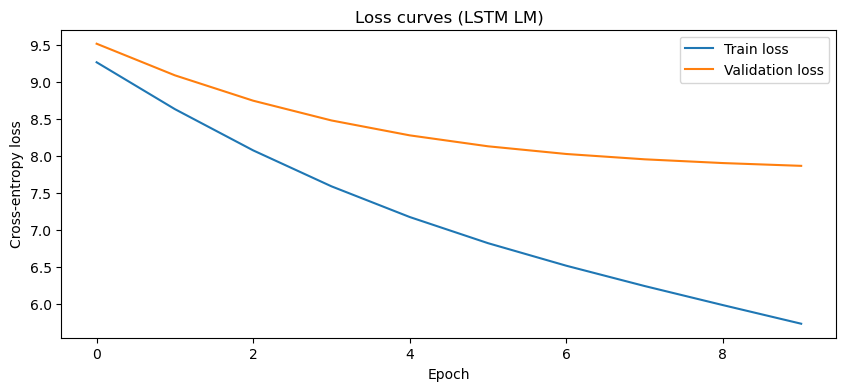

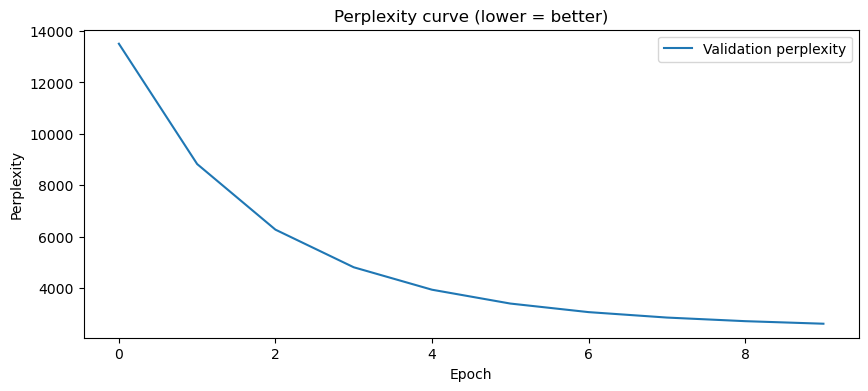

In [22]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss curves (LSTM LM)")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["ppl"], label="Validation perplexity")
plt.title("Perplexity curve (lower = better)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()



## Evaluation

In [23]:
# test loop
with torch.no_grad():
    model.eval()
    test_loss = 0.0
    count = 0

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        test_loss += loss.item()
        count += 1

    avg_test_loss = test_loss / max(count, 1)
    test_ppl = math.exp(avg_test_loss)

    print(f"Test loss={avg_test_loss:.4f} | Test perplexity={test_ppl:.2f}")

Test loss=7.2261 | Test perplexity=1374.87


In [24]:
# generate a sentence

start_text = "In a distant future"
start_enc = tokenizer.encode(start_text)
start_ids = torch.tensor(start_enc.ids, dtype=torch.long).unsqueeze(0)
generated_ids = model.sample(
    batch_size=1,
    num_steps=50,
    temperature=1.0,
    start_tokens=start_ids,
    device=device
)
generated_ids = generated_ids.squeeze(0).tolist()
generated_text = tokenizer.decode(generated_ids)
print("Generated text:")
print(generated_text)

Generated text:
inda Ġassociated 56 rong Ġenforcement Ġwas ĠUnion ĠEngland Ġbeing Ġon . Ċ Ġparts ootball ĠGreece ctors In iper Ġcrucial ations Ġtend Ġsymmetry Off Ġthe Ġanarchists Ġplatform Ġbeing Ġmassac Ġhelping missions Ġprogress res


### Measure Perplexity